In [1]:
import os
import gc
import csv
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torchvision.io import read_image
from torchvision import models
from torchvision.transforms import v2 as transforms
from torch.utils.data import Dataset, SubsetRandomSampler
from safetensors.torch import save_model, load_model
import torchvision.transforms.functional as F
from sklearn.metrics import confusion_matrix

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
class SquarePad:
    def __call__(self, image):
        c, h, w = image.size()
        max_wh = np.max([w, h])
        hp = (max_wh - w) // 2 + max_wh // 10
        vp = (max_wh - h) // 2 + max_wh // 10
        padding = (hp, vp, hp, vp)
        return F.pad(image, padding, 1, 'constant')

def image_transform(test=False):
    # normalize = transforms.Normalize(
    #     mean=[0.4914, 0.4822, 0.4465],
    #     std=[0.2023, 0.1994, 0.2010],
    # )
    mid_transforms = [
    ] if test else [
        # transforms.RandomHorizontalFlip(),
        # transforms.RandomVerticalFlip(),
        transforms.RandomAffine(degrees=10, translate=(0.1,0.1), scale=(0.9,1.1)),
        transforms.ColorJitter(),
        # transforms.GaussianBlur(5),
    ]
    return transforms.Compose([
        transforms.ConvertImageDtype(torch.float),
        transforms.RGB(),
        SquarePad(),
    ] + mid_transforms + [
        transforms.Resize((224,224)),
        # normalize,
        transforms.Lambda(lambda x: torch.clamp(x, 0, 1))
    ])


def load_image(path):
    transform = image_transform(test=True)
    image = read_image(path)
    image = transform(image)
    return image

In [4]:
# Load data from training
classification = torch.load('../models/text_detect.pt')
classification_path = pd.read_csv('../models/text_detect.csv', header=None, index_col=None)[0].tolist()

In [5]:
text_indices = []
logo_indices = []
unidentified_indices = []
for i in range(len(classification_path)):
    cl = classification[i]
    if cl[0] >= 0.5: # 50% confidence of text
        text_indices.append(i)
    if cl[1] >= 0.5: # 50% confidence of logo
        logo_indices.append(i)
    if cl[0] < 0.5 and cl[1] < 0.5:
        unidentified_indices.append(i)
print(len(text_indices))
print(len(logo_indices))
unidentified_indices

355
704


[443]

60it [00:00, 86.26it/s] 


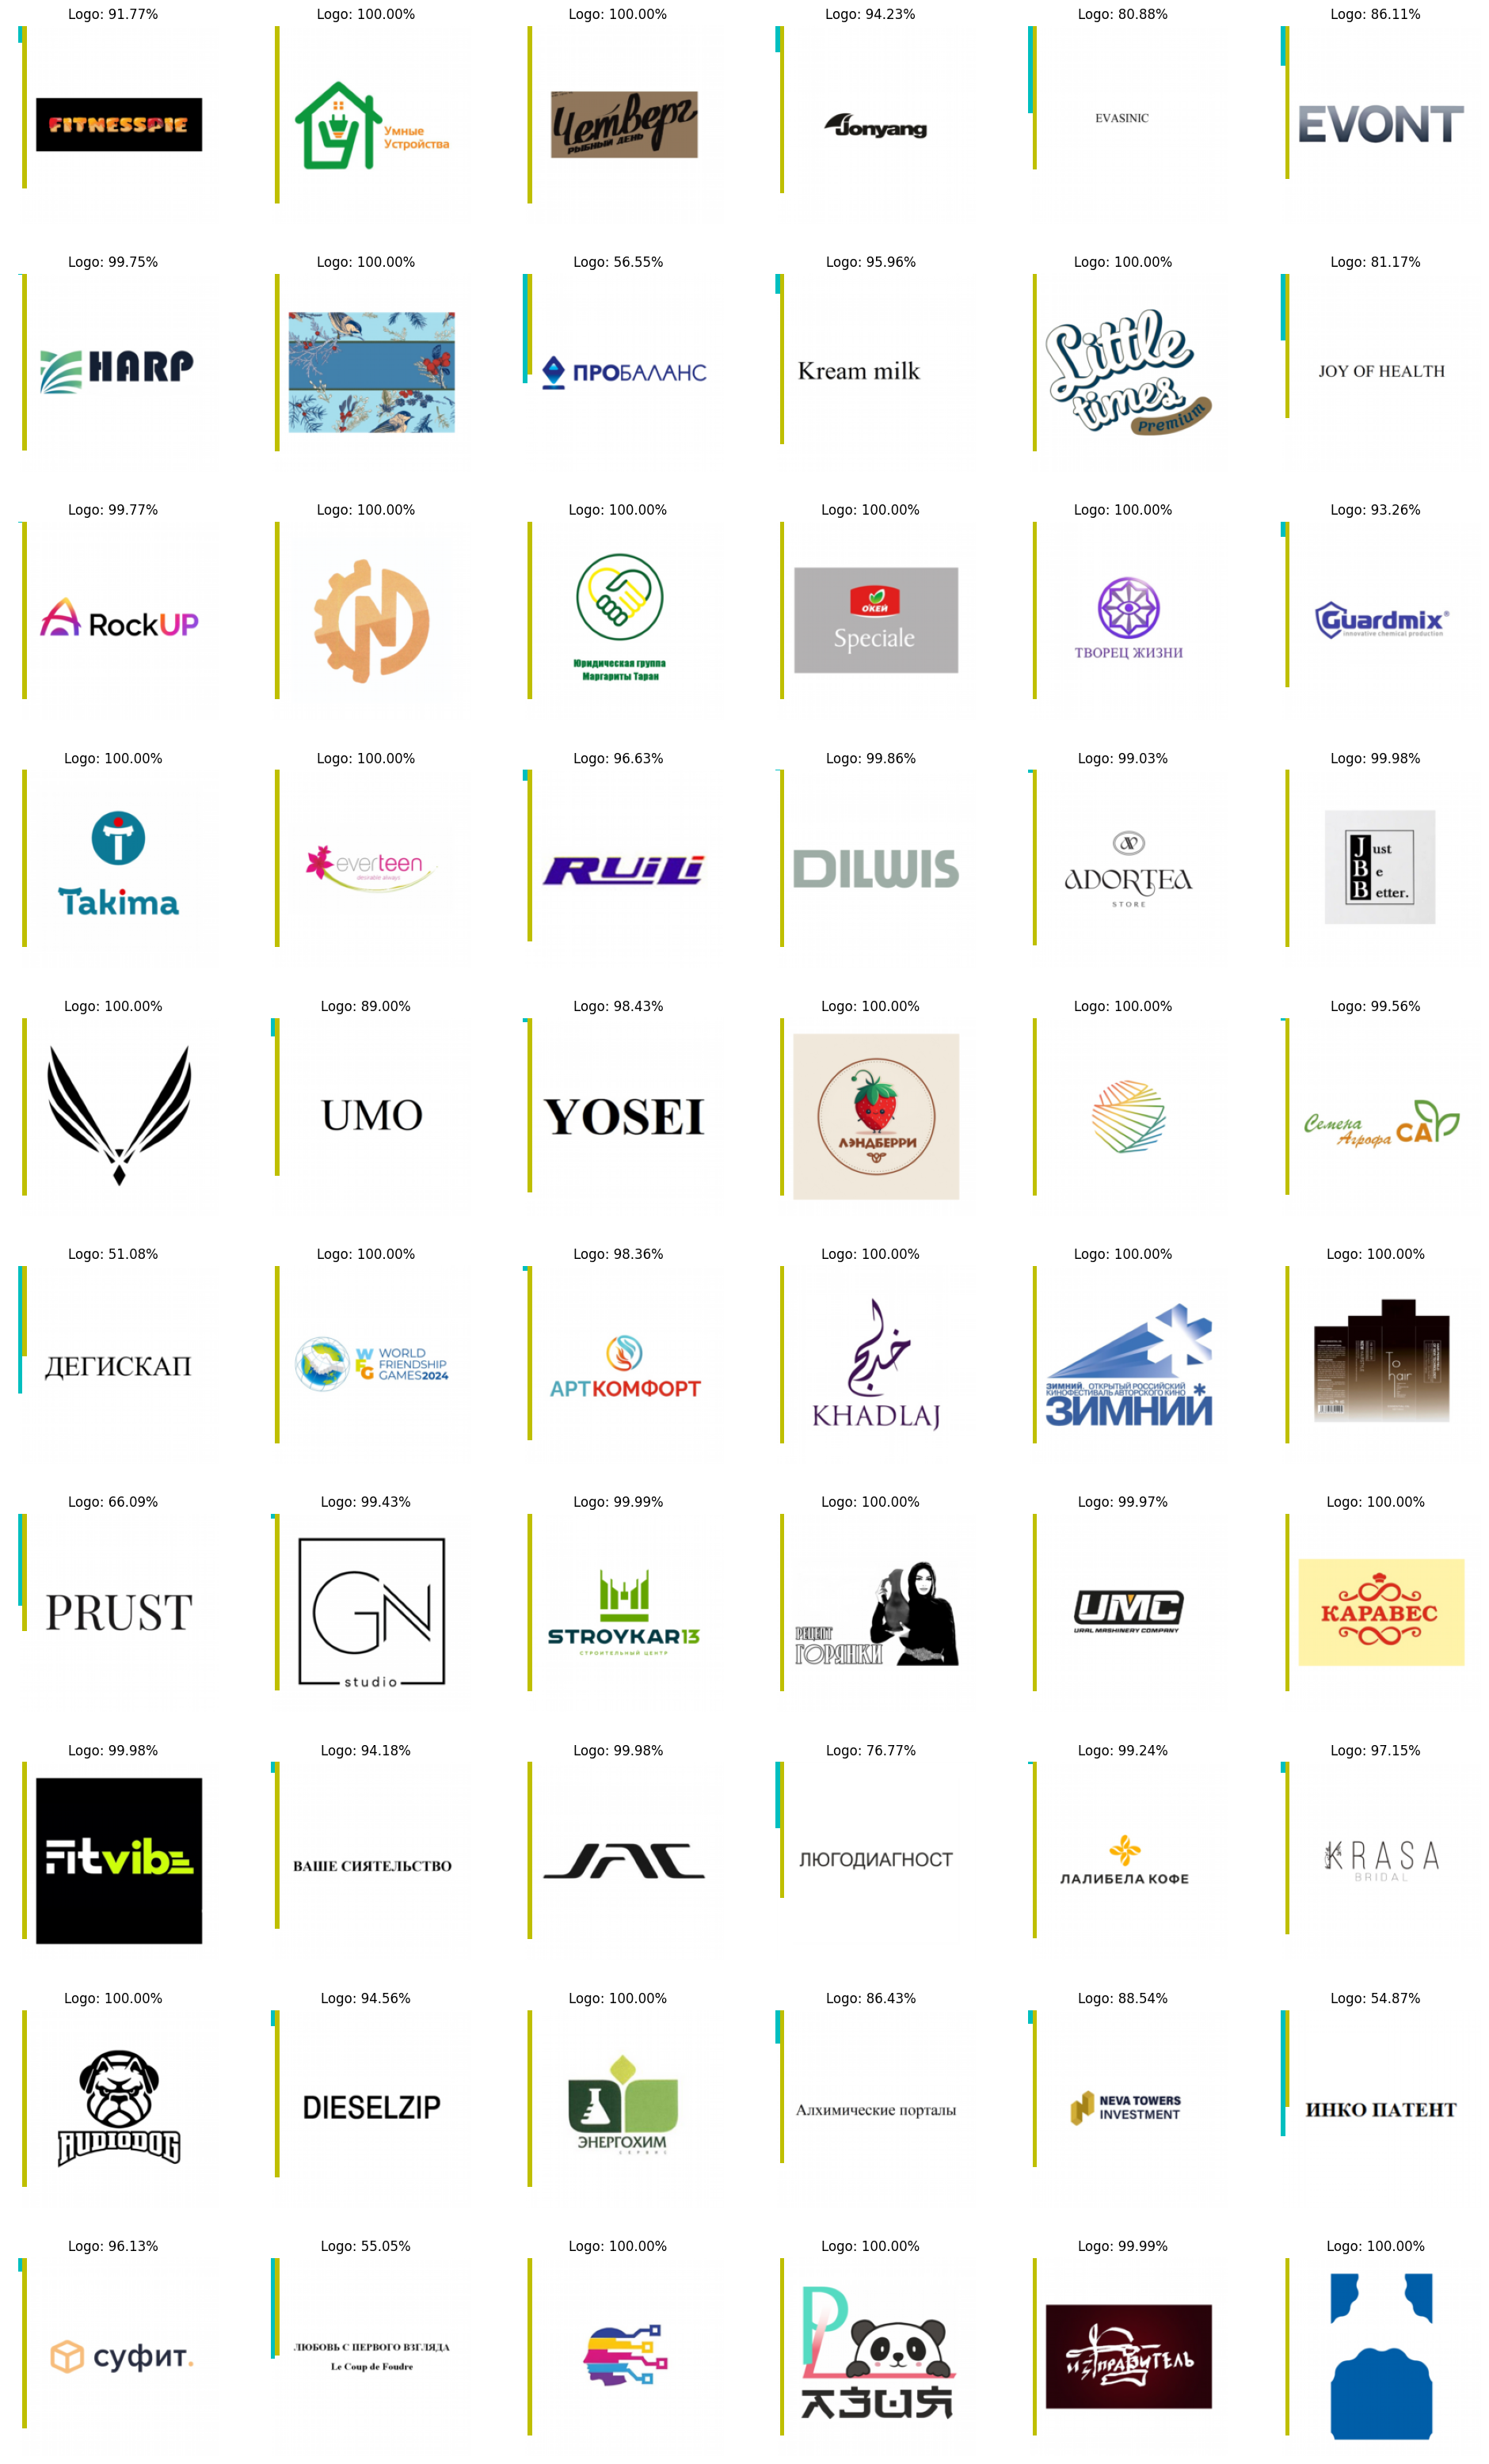

In [6]:
# Use the text-detection model to only check logos
w, h = 6, 10
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

np.random.shuffle(logo_indices)

for img_index, ax in tqdm(zip(logo_indices, axs.flatten())):
    img_path = classification_path[img_index]
    cl = classification[img_index].detach().cpu().numpy().flatten()
    text_condifence = cl[0] * 100
    logo_confidence = cl[1] * 100

    img = load_image(img_path)
    ax.set_title(f'Logo: {logo_confidence:.2f}%', )
    ax.set_axis_off()
    ax.imshow(img.transpose(0,1).transpose(1,2))
    ax.bar(0, cl[0] * 200, width=5, color='c')
    ax.bar(5, cl[1] * 200, width=5, color='y')
plt.show()

60it [00:00, 161.88it/s]


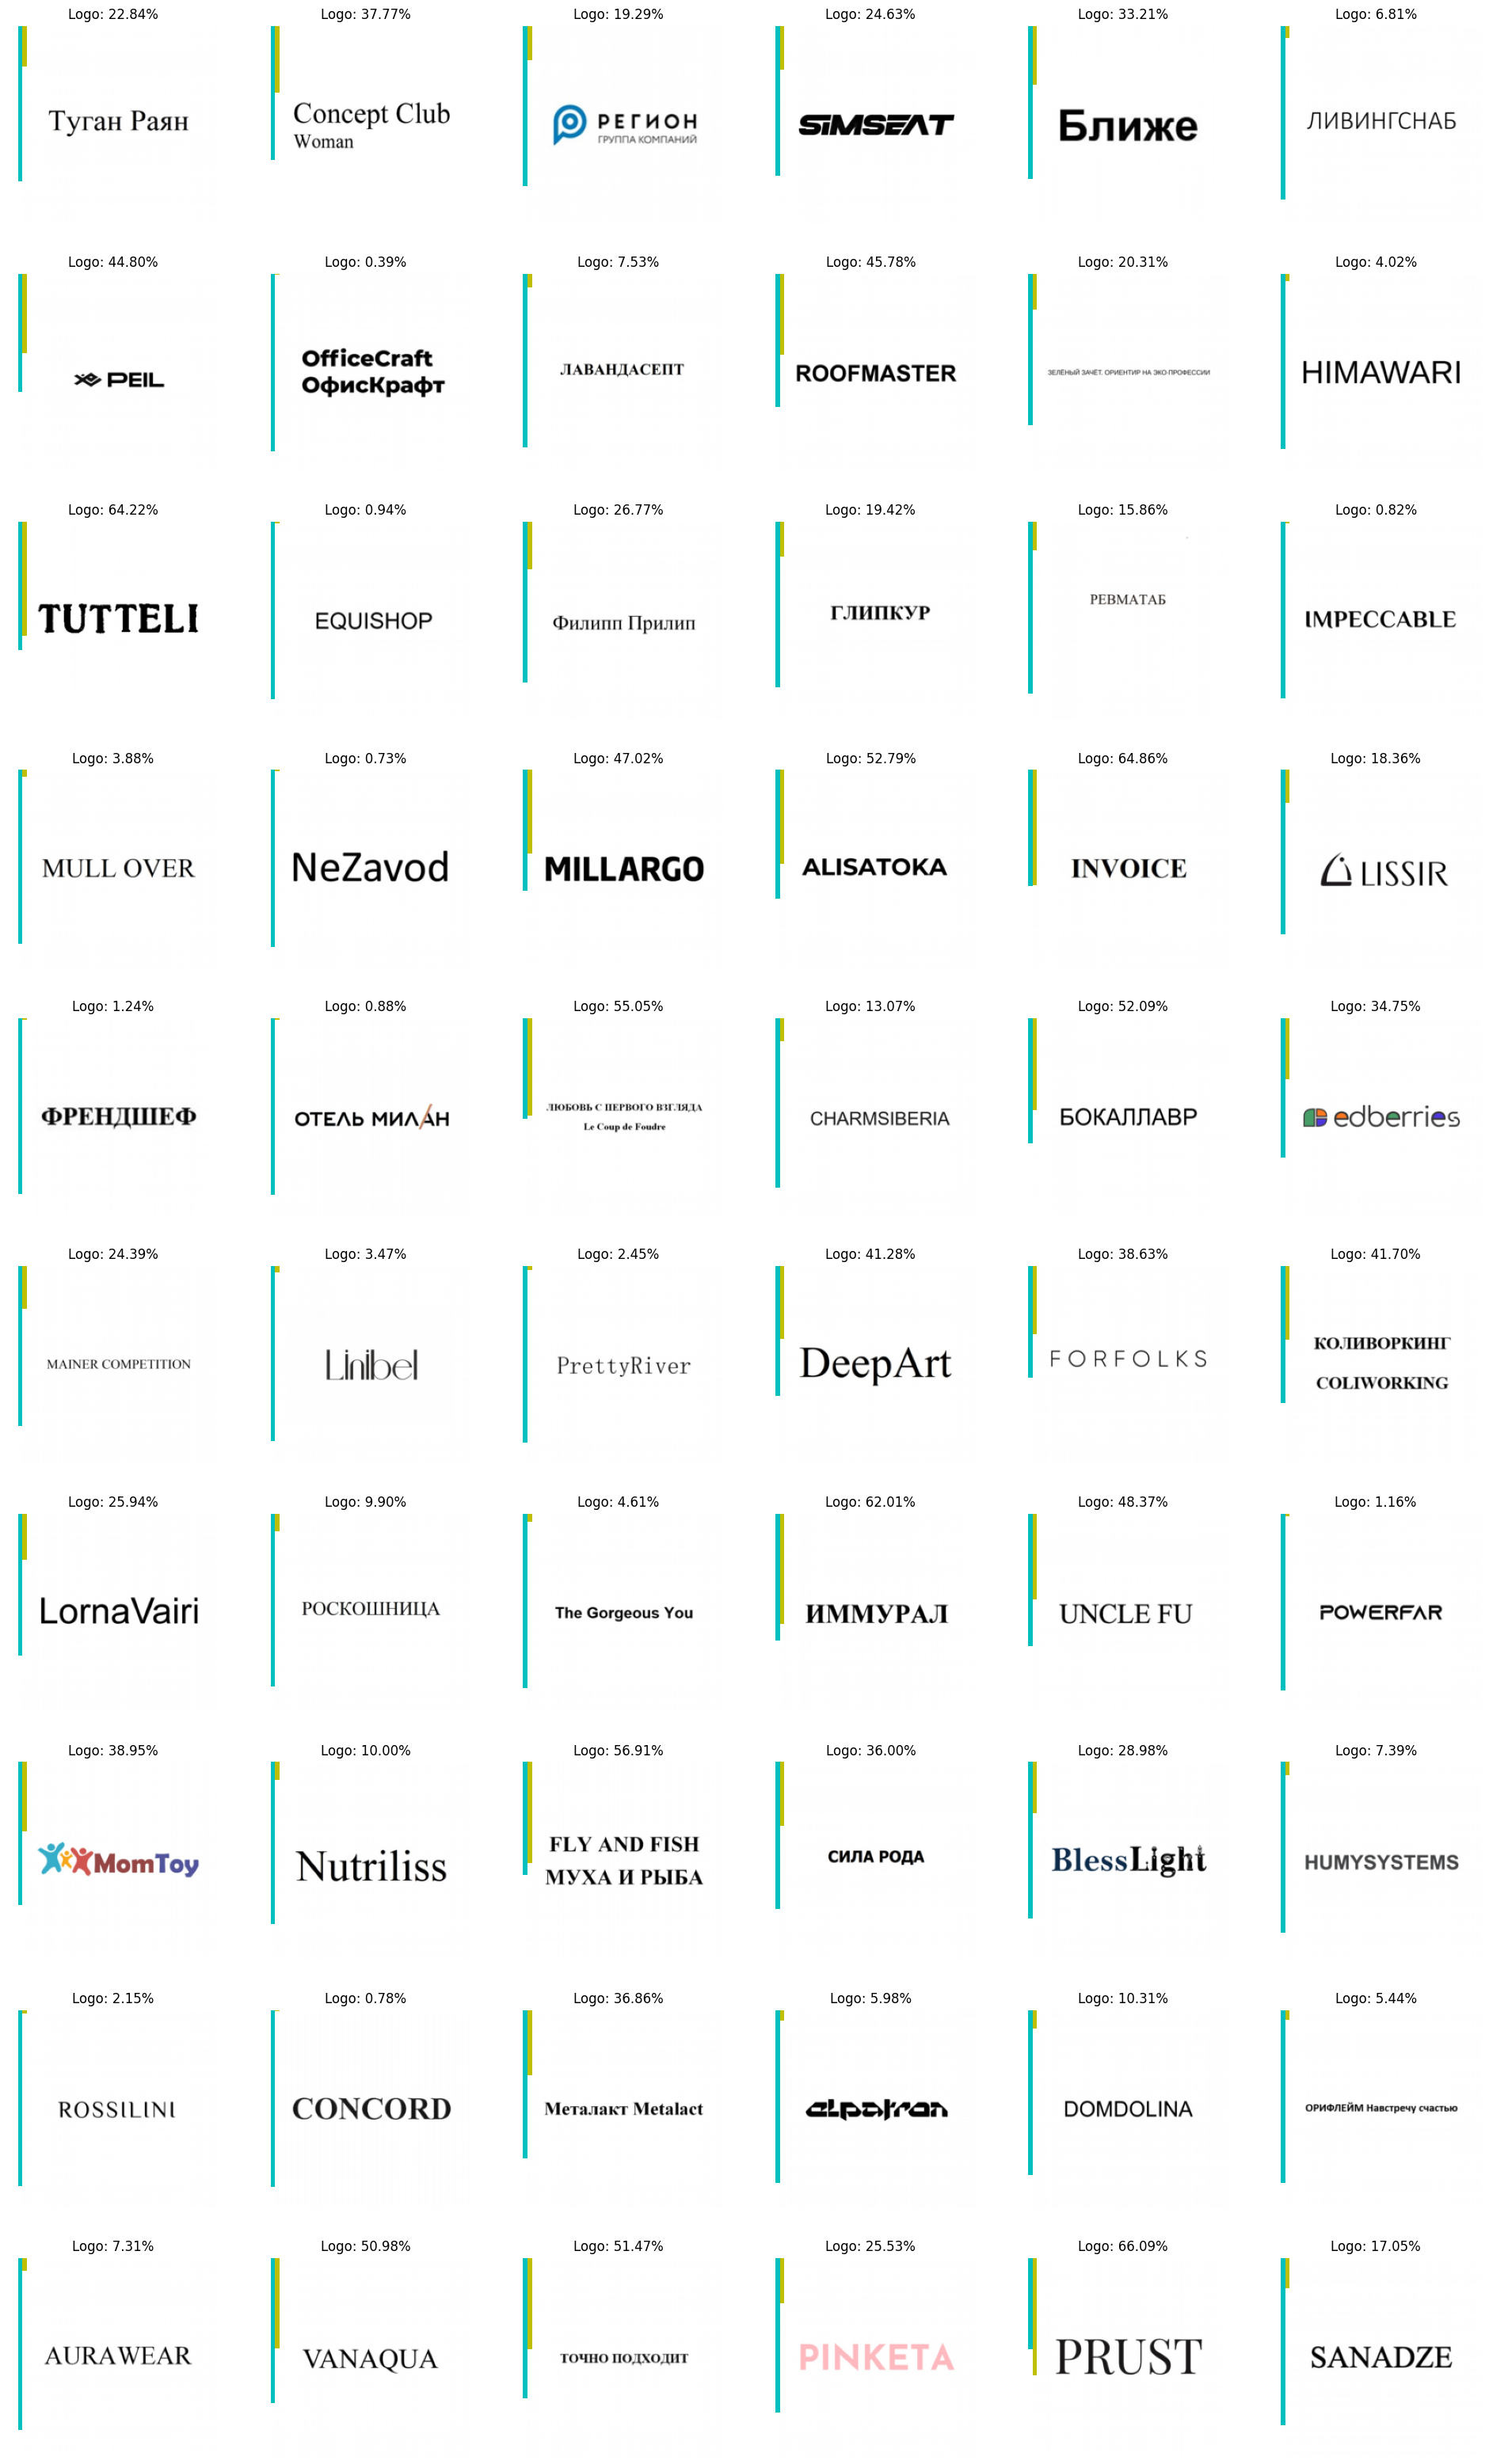

In [7]:
w, h = 6, 10
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

np.random.shuffle(text_indices)

for img_index, ax in tqdm(zip(text_indices, axs.flatten())):
    img_path = classification_path[img_index]
    cl = classification[img_index].detach().cpu().numpy().flatten()
    text_condifence = cl[0] * 100
    logo_confidence = cl[1] * 100

    img = load_image(img_path)
    ax.set_title(f'Logo: {logo_confidence:.2f}%', )
    ax.set_axis_off()
    ax.imshow(img.transpose(0,1).transpose(1,2))
    ax.bar(0, cl[0] * 200, width=5, color='c')
    ax.bar(5, cl[1] * 200, width=5, color='y')
plt.show()

1it [00:00, 68.07it/s]


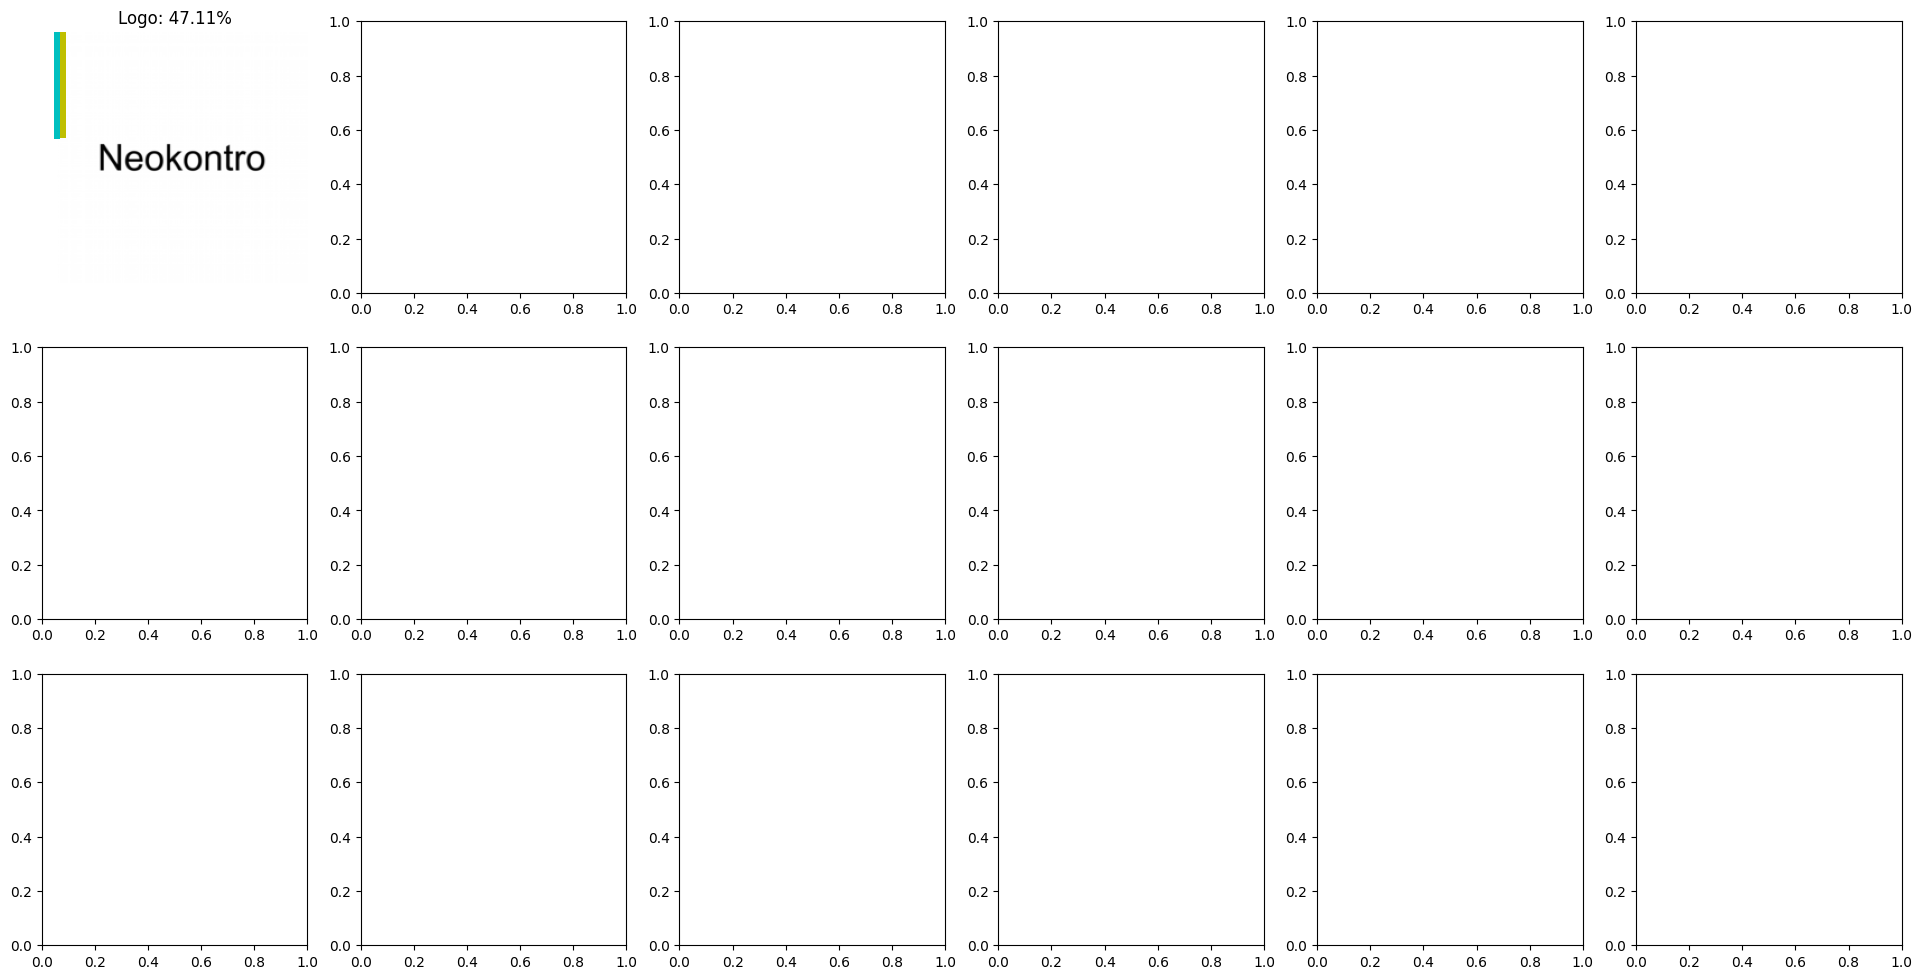

In [8]:
w, h = 6, 3
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

np.random.shuffle(unidentified_indices)

for img_index, ax in tqdm(zip(unidentified_indices, axs.flatten())):
    img_path = classification_path[img_index]
    cl = classification[img_index].detach().cpu().numpy().flatten()
    text_condifence = cl[0] * 100
    logo_confidence = cl[1] * 100

    img = load_image(img_path)
    ax.set_title(f'Logo: {logo_confidence:.2f}%', )
    ax.set_axis_off()
    ax.imshow(img.transpose(0,1).transpose(1,2))
    ax.bar(0, cl[0] * 200, width=5, color='c')
    ax.bar(5, cl[1] * 200, width=5, color='y')
plt.show()

In [9]:
model = models.vgg16()
model.classifier.append(nn.Linear(1000, 2)) # 2 classes: text, logo
model.classifier.append(nn.Sigmoid())

load_model(model, '../models/text_detect.safetensors')

model = model.to(device)
model.eval()
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [10]:
def load_paths(root_dir, list_path=None) -> list:
    if list_path is None:
        filenames = next(os.walk(root_dir), (None, None, []))[2]
        return [os.path.join(root_dir, filename) for filename in filenames]
    else:
        filenames = pd.read_csv(list_path, header=None, index_col=None)
        return [os.path.join(root_dir, filename) for _, row in filenames.items() for filename in row ]

In [11]:
class LogosDataset(Dataset):
    def __init__(self, root_dir, list_path, frames_limit=None, transform=None):
        self.root = root_dir
        self.transform = transform

        self.images = []

        images = load_paths(root_dir, list_path)
        image_paths = []

        if frames_limit is None:
            image_paths = images
        else:
            np.random.shuffle(images)
            image_paths.extend(images[:frames_limit])

        self.images.extend(image_paths)

        print(f'loaded {len(self.images)} paths')

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = read_image(img_path)
        if self.transform:
            image = self.transform(image)
        return image, img_path

In [12]:
def data_loader(data_dir, list_path, batch_size, frames_limit=None, shuffle=True, test=False):
    transform = image_transform(test)
    dataset = LogosDataset(data_dir, list_path, frames_limit, transform)

    indices = list(range(len(dataset)))
    if shuffle:
        np.random.shuffle(indices)

    sampler = SubsetRandomSampler(indices)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=sampler)
    return loader

In [13]:
logos_loader_valid = data_loader('../data/logos', '../data/logos_valid.csv', 16)
text_loader_valid = data_loader('../data/logos', '../data/text_valid.csv', 16)

loaded 50 paths
loaded 48 paths


In [14]:
# Evaluate the model with the validation dataset
labels_expected = []
labels_predicted = []

for images, image_paths in tqdm(logos_loader_valid):
    images = images.to(device)
    classification = model(images).detach().cpu().numpy()

    for cl in classification:
        if cl[1] >= 0.5: # 50% confidence of logo
            labels_predicted.append(1)
        elif cl[0] >= 0.5: # 50% confidence of text
            labels_predicted.append(0)
        else:
            labels_predicted.append(2)
        labels_expected.append(1)

for images, image_paths in tqdm(text_loader_valid):
    images = images.to(device)
    classification = model(images).detach().cpu().numpy()

    for cl in classification:
        if cl[1] >= 0.5: # 50% confidence of logo
            labels_predicted.append(1)
        elif cl[0] >= 0.5: # 50% confidence of text
            labels_predicted.append(0)
        else:
            labels_predicted.append(2)
        labels_expected.append(0)

100%|██████████| 3/3 [00:02<00:00,  1.10it/s]


In [15]:
confusion = confusion_matrix(labels_expected, labels_predicted)
confusion

array([[25, 23],
       [ 1, 49]])

In [16]:
true_logo = confusion[0][0]
false_text = confusion[0][1]
false_logo = confusion[1][0]
true_text = confusion[1][1]
true_logo, false_text, false_logo, true_text

(np.int64(25), np.int64(23), np.int64(1), np.int64(49))

In [17]:
acc = (true_logo + true_text) / (true_logo + true_text + false_logo + false_text)
print(f'Accuracy: {acc:.5}')

print()
prec = true_logo / (true_logo + false_logo)
print(f'Precision (logo): {prec:.5}')
recall = true_logo / (true_logo + false_text)
print(f'Recall (logo): {recall:.5}')
f1 = prec * recall / (prec + recall)
print(f'F1 (logo): {f1:.5}')

print()
prec_text = true_text / (true_text + false_text)
print(f'Precision (text): {prec_text:.5}')
recall_text = true_text / (true_text + false_logo)
print(f'Recall (text): {recall_text:.5}')
f1_text = prec_text * recall_text / (prec_text + recall_text)
print(f'F1 (text): {f1_text:.5}')

Accuracy: 0.7551

Precision (logo): 0.96154
Recall (logo): 0.52083
F1 (logo): 0.33784

Precision (text): 0.68056
Recall (text): 0.98
F1 (text): 0.40164
